In [1]:
from shapely.geometry import Point

Point_of_Interest = Point(-85.57606002445266, 29.478421311283924).buffer(1.5)

area =[
    Point_of_Interest.bounds[0], Point_of_Interest.bounds[2],
    Point_of_Interest.bounds[1], Point_of_Interest.bounds[3]
]

In [ ]:
import xarray as xr

# Load GEBCO 2025 data from remote server
GEBCO = xr.open_dataset(
    "https://dap.ceda.ac.uk/thredds/dodsC/bodc/gebco/global/gebco_2025/ice_surface_elevation/netcdf/GEBCO_2025.nc"
)
# Extract the region of interest
GEBCO_sel = GEBCO.sel(
    lon=slice(area[0], area[1]),
    lat=slice(area[2], area[3])
)

GEBCO_sel

<xarray.Dataset> Size: 1MB
Dimensions:    (lat: 720, lon: 720)
Coordinates:
  * lat        (lat) float64 6kB 27.98 27.99 27.99 27.99 ... 30.97 30.97 30.98
  * lon        (lon) float64 6kB -87.07 -87.07 -87.06 ... -84.09 -84.08 -84.08
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) int16 1MB ...
Attributes: (12/36)
    title:                           The GEBCO_2026 Grid - a continuous terra...
    summary:                         The GEBCO_2026 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/4f68d5c7-45eb-f999-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/4f68d5c7-45eb-f999-e063-708...
    references:                      DOI: 10.5285/4f68d5c7-45eb-f999-e063-708...
    node_offset:                     1.0

In [3]:
import numpy as np

GEBCO_sel["elevation"] = GEBCO_sel["elevation"].where(GEBCO_sel["elevation"] < 1, np.nan)

Using Esri World Imagery (ArcGIS):
- Free for public and non-commercial use
- Commercial use allowed under Esri terms of service
- Attribution required: 'Tiles © Esri — Sources: Esri, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community'
- Max zoom ~19


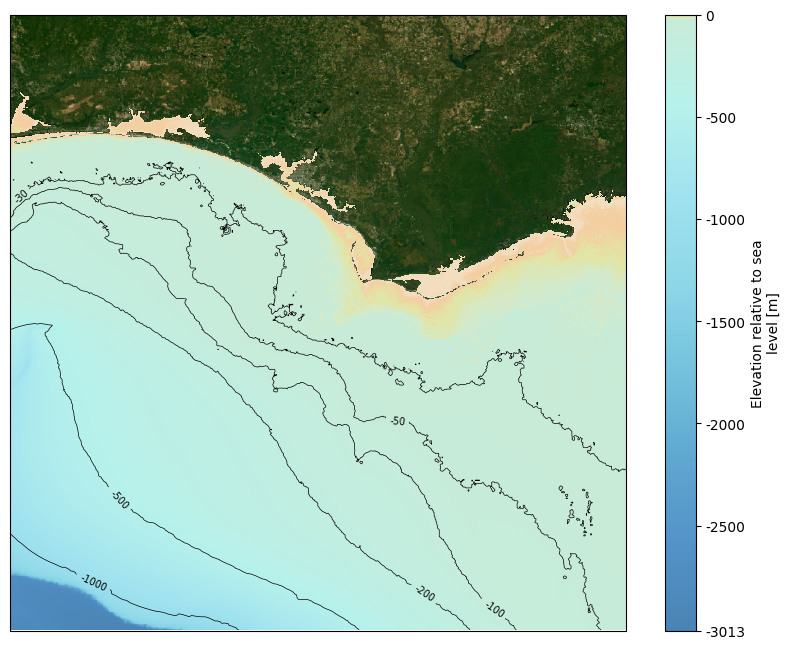

In [4]:
from bluemath_tk.core.plotting.base_plotting import DefaultStaticPlotting
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
plot = DefaultStaticPlotting()

plot.plot_satellite(ax=ax, source="arcgis", area=area)
plot.plot_bathymetry(source = GEBCO_sel,ax = ax, area = area, var_name = "elevation", transition_depth = -20, isodepths = [-1000, -500, -200, -100, -50, -30])
